In [1]:
# pip install paddleocr
# pip install paddlepaddle
# pip install opencv-python
# pip install pillow
# pip install pymupdf
#pip uninstall paddleocr paddlepaddle paddlex -y
# pip install paddleocr==2.7.3

## steps file
* 1- PaddleOCR setup
* 2- Convert a single-page PDF to an image
* 3- Prepare the file (Image or PDF)
* 4- Image improvement
* > Remove noise
* > Improve contrast
* > Black and white conversion
* 5- show image
* 6- OCR operation
* 7- Extracting text from OCR results
* 8- Text cleaning
* 9- HbA1c extraction
* 10- extract_glucose
* 11- Standardizing abbreviations
<!-- * 5- Medical Field Detection (Regex + Keywords) -->

In [2]:
# import os

# os.environ["FLAGS_use_mkldnn"] = "0"

In [3]:
# import sys

# print(sys.executable)
!{sys.executable} -m pip install --upgrade requests urllib3 charset-normalizer
!{sys.executable} -m pip install ipywidgets


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import numpy as np

print(np.__version__)

1.26.4


In [5]:
import os
import cv2
import re
import fitz
import numpy as np
from paddleocr import PaddleOCR

* 1- PaddleOCR setup


In [6]:
ocr = PaddleOCR(
    lang="en"
)

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to C:\Users\lenovo/.paddleocr/whl\det\en\en_PP-OCRv3_det_infer\en_PP-OCRv3_det_infer.tar


100%|██████████| 4.00M/4.00M [00:49<00:00, 80.4kiB/s]


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to C:\Users\lenovo/.paddleocr/whl\rec\en\en_PP-OCRv4_rec_infer\en_PP-OCRv4_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:48<00:00, 209kiB/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to C:\Users\lenovo/.paddleocr/whl\cls\ch_ppocr_mobile_v2.0_cls_infer\ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2.19M/2.19M [00:54<00:00, 40.0kiB/s]

[2026/07/26 12:32:53] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\lenovo/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\lenovo/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

* 2- Convert a single-page PDF to an image


In [36]:
def pdf_to_image(pdf_path):

    pdf = fitz.open(pdf_path)

    page = pdf[0]

    pix = page.get_pixmap(
        dpi=300
    )

    image_path = "pdf_page.png"

    pix.save(image_path)

    return image_path

* 3- Prepare the file (Image or PDF)


In [37]:
def prepare_file(file_path):

    ext = os.path.splitext(file_path)[1].lower()


    if ext == ".pdf":

        image_path = pdf_to_image(
            file_path
        )


    elif ext in [
        ".jpg",
        ".jpeg",
        ".png"
    ]:

        image_path = file_path


    else:

        raise Exception(
            "Unsupported file"
        )


    return image_path

* 4- Image improvement


In [38]:
def preprocess_image(image_path):

    img = cv2.imread(
        image_path
    )


    # Gray
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

# Remove noise
    denoise = cv2.fastNlMeansDenoising(
        gray,
        None,
        30,
        7,
        21
    )


   # Improve contrast
    contrast = cv2.equalizeHist(
        denoise
    )


    # Threshold
    thresh = cv2.threshold(
        contrast,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]


    output = "processed.png"


    cv2.imwrite(
        output,
        thresh
    )


    return output

* 5- show image

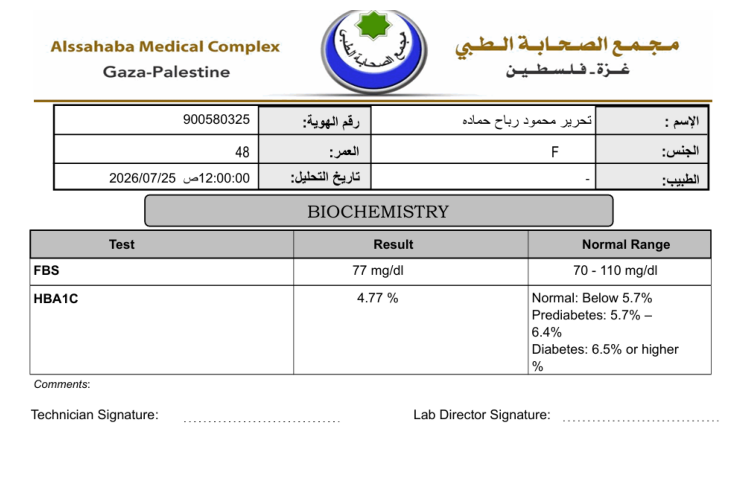

In [39]:
from matplotlib import pyplot as plt

img = cv2.imread("ocr image.png")

plt.figure(figsize=(10,6))
plt.imshow(img,cmap="gray")
plt.axis("off");

* 6- OCR operation


In [40]:
def run_ocr(image_path):

    result = ocr.ocr(
        image_path,
        cls=True
    )

    return result

* 7- Extracting text from OCR results


In [41]:
def extract_text(result):

    text = ""

    for page in result:

        for line in page:

            word = line[1][0]

            text += word + " "

    return text

* 8- Text cleaning


In [42]:
def clean_text(text):

    replacements = {

        "HbAlc":"HbA1c",
        "HBAIC":"HbA1c",
        "HBA1C":"HbA1c",
        "Hb Alc":"HbA1c"

    }


    for old,new in replacements.items():

        text = text.replace(
            old,
            new
        )


    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text

* 9- HbA1c extraction


In [50]:
def extract_hba1c(text):

    patterns = [

        r"HbA1c\s*[:\-]?\s*(\d+[.,]\d+)",

        r"A1c\s*[:\-]?\s*(\d+[.,]\d+)",

    ]


    for pattern in patterns:

        match = re.search(
            pattern,
            text,
            re.IGNORECASE
        )

        if match:

            value = match.group(1)

            value = value.replace(
                ",",
                "."
            )

            return float(value)


    return None

* 10- extract_glucose

In [51]:
def extract_glucose(text):

    patterns = [

        r"FBS\s*[:\-]?\s*(\d+)",

        r"FBG\s*[:\-]?\s*(\d+)",

        r"Fasting\s+Blood\s+Sugar\s*[:\-]?\s*(\d+)",

        r"Fasting\s+Glucose\s*[:\-]?\s*(\d+)",

        r"Blood\s+Glucose\s*[:\-]?\s*(\d+)",

        r"Glucose\s*[:\-]?\s*(\d+)",

    ]


    for pattern in patterns:

        match = re.search(
            pattern,
            text,
            re.IGNORECASE
        )

        if match:
            return int(match.group(1))


    return None

* 11- Standardizing abbreviations

In [52]:
def normalize_medical_terms(text):

    replacements = {

        "HBAIC": "HbA1c",
        "HBA1C": "HbA1c",
        "HbAlc": "HbA1c",
        "HBAIC": "HbA1c",

        "F8S": "FBS",
        "FB5": "FBS"

    }


    for old, new in replacements.items():

        text = text.replace(
            old,
            new
        )


    # تحويل الفواصل العشرية
    text = text.replace(
        ",",
        "."
    )


    return text

In [53]:
def extract_medical_values(text):

    return {
        "HbA1c": extract_hba1c(text),
        "Blood_Glucose": extract_glucose(text)
    }

In [46]:
# print(paddle.__version__)
# print(paddleocr.__version__)

In [54]:
file_path = "ocr image.png"   # غيرها إلى اسم الصورة
# file_path = "test_report.pdf" # جرب الـ PDF بعد ذلك


image = prepare_file(file_path)

print("Image used for OCR:")
print(image)


processed = preprocess_image(image)

print("Processed image:")
print(processed)


result = run_ocr(processed)

text = extract_text(result)

print("\n===== OCR TEXT =====")
print(text)


text = normalize_medical_terms(text)
text = clean_text(text)


values = extract_medical_values(text)

print("\n===== Extracted Values =====")
print(values)

Image used for OCR:
ocr image.png
Processed image:
processed.png
[2026/07/26 12:40:10] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/07/26 12:40:10] ppocr DEBUG: dt_boxes num : 21, elapsed : 0.12752199172973633
[2026/07/26 12:40:11] ppocr DEBUG: rec_res num  : 21, elapsed : 1.0845038890838623

===== OCR TEXT =====
1 900580325 48 F 2026/07/2512:00:00 FBS 77 mg/dl 70-110 mg/dl HBAIC 4,77 % NomaltBelow 5.7% Prediabetes5.7%- 6.4% Dlabetes: 6.5% or higher P Commonts: Technldan Signature: Lab Dlrector Signature: 

===== Extracted Values =====
{'HbA1c': 4.77, 'Blood_Glucose': 77}


# praper ocr model to mobile app

In [55]:
def extract_lab_values(file_path):

    image = prepare_file(file_path)

    processed = preprocess_image(image)

    result = run_ocr(processed)

    text = extract_text(result)

    text = normalize_medical_terms(text)
    text = clean_text(text)

    values = extract_medical_values(text)

    return values

In [58]:
result = extract_lab_values(
    "ocr_file.pdf"
)

print(result)

[2026/07/26 12:50:52] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/07/26 12:50:53] ppocr DEBUG: dt_boxes num : 24, elapsed : 0.7409646511077881
[2026/07/26 12:50:54] ppocr DEBUG: rec_res num  : 24, elapsed : 1.1322650909423828
{'HbA1c': 4.77, 'Blood_Glucose': 77}
